# LAB02 — Auditoría de Online Shoppers Purchasing Intention

## Dataset seleccionado

**Online Shoppers Purchasing Intention**

- Fuente: UCI Machine Learning Repository
- Target: `Revenue`
- Tipo de problema: clasificación binaria
- Unidad de análisis: una sesión de navegación de un visitante en un sitio de comercio electrónico
- Uso: académico

## Objetivo del notebook

Auditar la estructura, calidad y consistencia del dataset antes de construir los modelos de clasificación. Se revisarán dimensiones, tipos de datos, valores ausentes, registros duplicados, distribución del target, disponibilidad temporal de las variables y posibles riesgos de fuga de información.

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = (
    project_root
    / "data"
    / "raw"
    / "online_shoppers_intention.csv"
)

df = pd.read_csv(data_path)

print("Ruta:", data_path)
print("Dimensiones originales:", df.shape)

Ruta: c:\Users\Gladys\INF8239_U01\data\raw\online_shoppers_intention.csv
Dimensiones originales: (12330, 18)


## Revisión de registros duplicados

Se verificará la existencia de registros duplicados exactos y de patrones repetidos en las variables predictoras. Esta revisión es importante para evitar que observaciones idénticas aparezcan simultáneamente en los conjuntos de entrenamiento y prueba.

In [3]:
target = "Revenue"

exact_duplicates = df.duplicated().sum()

X_temp = df.drop(columns=[target])
predictor_duplicates = X_temp.duplicated(keep=False).sum()

target_variation = (
    df.groupby(
        [column for column in df.columns if column != target],
        dropna=False,
    )[target]
    .nunique()
)

conflicting_patterns = (target_variation > 1).sum()

print("Duplicados exactos:", exact_duplicates)
print("Filas con predictores duplicados:", predictor_duplicates)
print("Grupos de predictores con Revenue diferente:", conflicting_patterns)

Duplicados exactos: 125
Filas con predictores duplicados: 201
Grupos de predictores con Revenue diferente: 0


### Decisión sobre duplicados

Se identificaron 125 registros duplicados exactos. Además, las repeticiones encontradas en las variables predictoras no presentan valores diferentes en el target `Revenue`.

Para reducir el riesgo de contaminación entre entrenamiento y prueba, se eliminarán únicamente los duplicados exactos antes de realizar la partición del dataset. El archivo original permanecerá sin modificaciones y la limpieza se realizará mediante código para conservar la trazabilidad del proceso.

In [4]:
df_clean = df.drop_duplicates().copy()

print("Dimensiones originales:", df.shape)
print("Dimensiones después de eliminar duplicados:", df_clean.shape)
print("Registros eliminados:", len(df) - len(df_clean))

Dimensiones originales: (12330, 18)
Dimensiones después de eliminar duplicados: (12205, 18)
Registros eliminados: 125


## Auditoría de tipos de datos y variable objetivo

Se revisarán los tipos de datos de las variables, la existencia de valores ausentes y la distribución de la variable objetivo `Revenue`. Esta información permitirá definir posteriormente qué variables requieren tratamiento numérico o categórico y evaluar el nivel de desbalance entre las clases.

In [5]:
print("Tipos de datos:")
print(df_clean.dtypes.value_counts())

print("\nValores ausentes totales:")
print(df_clean.isna().sum().sum())

print("\nNúmero de clases en Revenue:")
print(df_clean["Revenue"].nunique())

print("\nDistribución de Revenue:")
print(df_clean["Revenue"].value_counts())

print("\nDistribución porcentual de Revenue:")
print(
    df_clean["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Tipos de datos:
int64      7
float64    7
str        2
bool       2
Name: count, dtype: int64

Valores ausentes totales:
0

Número de clases en Revenue:
2

Distribución de Revenue:
Revenue
False    10297
True      1908
Name: count, dtype: int64

Distribución porcentual de Revenue:
Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64


## Revisión semántica de las variables

El tipo de dato asignado por Pandas no determina necesariamente la naturaleza de una variable. Algunas características almacenadas como números representan códigos de categorías, por lo que se revisarán los nombres, tipos y cantidad de valores únicos antes de definir las variables numéricas y categóricas.

In [6]:
variable_audit = pd.DataFrame({
    "tipo_pandas": df_clean.dtypes.astype(str),
    "valores_unicos": df_clean.nunique(),
})

variable_audit

,tipo_pandas,valores_unicos
Administrative,int64,27
Administrative_Duration,float64,3335
Informational,int64,17
Informational_Duration,float64,1258
ProductRelated,int64,311
ProductRelated_Duration,float64,9551
BounceRates,float64,1872
ExitRates,float64,4777
PageValues,float64,2704
SpecialDay,float64,6


### Clasificación de variables

La clasificación de las variables se realizó considerando su significado y no únicamente el tipo de dato asignado por Pandas. Algunas variables almacenadas como números, tales como `OperatingSystems`, `Browser`, `Region` y `TrafficType`, representan códigos de categorías y serán tratadas como variables categóricas.

El target del problema es `Revenue`, que indica si la sesión finalizó o no en una compra.

In [7]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

target = "Revenue"

selected_columns = numeric_features + categorical_features + [target]

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Target:", target)
print("Total de columnas clasificadas:", len(selected_columns))
print("Total de columnas del dataset:", df_clean.shape[1])

assert set(selected_columns) == set(df_clean.columns)

Variables numéricas: 10
Variables categóricas: 7
Target: Revenue
Total de columnas clasificadas: 18
Total de columnas del dataset: 18


## Disponibilidad temporal y riesgo de fuga de información

El objetivo es predecir si una sesión de navegación finalizará en una compra (`Revenue`). Por tanto, las variables predictoras deben representar información que pueda estar disponible durante la sesión y antes de conocer el resultado final.

Las variables relacionadas con cantidad de páginas visitadas, duración de navegación, tipo de visitante, navegador, región, tráfico, mes y fin de semana pueden obtenerse a partir de la actividad o características de la sesión.

Se prestará especial atención a `PageValues`, ya que esta métrica está relacionada con el valor atribuido a las páginas visitadas antes de una transacción. Aunque forma parte del dataset original como predictor, se evaluará su uso cuidadosamente para evitar incorporar información que pudiera estar demasiado relacionada con el resultado que se desea predecir.

No se identifica por el momento una variable que corresponda directamente al target, aparte de `Revenue`, que será excluido de los predictores.

In [8]:
X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Revenue dentro de X:", target in X.columns)

Dimensiones de X: (12205, 17)
Dimensiones de y: (12205,)
Revenue dentro de X: False


## Diccionario de variables

El diccionario se construyó utilizando la documentación oficial del UCI Machine Learning Repository y la revisión semántica de las variables. Se incluye el significado de cada característica, su naturaleza, disponibilidad aproximada al momento de la predicción, tratamiento previsto y riesgo preliminar de fuga de información.

| Variable | Significado | Naturaleza / unidad | Disponibilidad | Transformación prevista | Riesgo |
|---|---|---|---|---|---|
| Administrative | Cantidad de páginas administrativas visitadas | Conteo | Durante la sesión | Escalado | Bajo |
| Administrative_Duration | Tiempo dedicado a páginas administrativas | Tiempo; UCI no especifica unidad | Durante la sesión | Escalado | Bajo |
| Informational | Cantidad de páginas informativas visitadas | Conteo | Durante la sesión | Escalado | Bajo |
| Informational_Duration | Tiempo dedicado a páginas informativas | Tiempo; UCI no especifica unidad | Durante la sesión | Escalado | Bajo |
| ProductRelated | Cantidad de páginas relacionadas con productos visitadas | Conteo | Durante la sesión | Escalado | Bajo |
| ProductRelated_Duration | Tiempo dedicado a páginas relacionadas con productos | Tiempo; UCI no especifica unidad | Durante la sesión | Escalado | Bajo |
| BounceRates | Tasa asociada a visitantes que abandonan después de entrar por una página | Proporción / métrica web | Durante la sesión | Escalado | Bajo/moderado |
| ExitRates | Porcentaje de vistas de una página que fueron las últimas de una sesión | Proporción / métrica web | Durante la sesión | Escalado | Bajo/moderado |
| PageValues | Valor medio atribuido a las páginas visitadas antes de una transacción | Métrica de analítica web | Durante la sesión | Escalado; evaluar también escenario sin esta variable | Moderado |
| SpecialDay | Cercanía temporal de la visita a una fecha especial | Escala de 0 a 1 | Disponible al inicio de la sesión | Escalado | Bajo |
| Month | Mes de la visita | Categórica | Disponible al inicio | One-Hot Encoding | Bajo |
| OperatingSystems | Código del sistema operativo utilizado | Categórica codificada | Disponible durante la sesión | One-Hot Encoding | Bajo |
| Browser | Código del navegador utilizado | Categórica codificada | Disponible durante la sesión | One-Hot Encoding | Bajo |
| Region | Código de región del visitante | Categórica codificada | Disponible durante la sesión | One-Hot Encoding | Bajo |
| TrafficType | Código que identifica el tipo/origen del tráfico | Categórica codificada | Disponible durante la sesión | One-Hot Encoding | Bajo |
| VisitorType | Tipo de visitante | Categórica | Disponible durante la sesión | One-Hot Encoding | Bajo |
| Weekend | Indica si la visita ocurrió durante el fin de semana | Booleana/categórica | Disponible al inicio | One-Hot Encoding | Bajo |
| Revenue | Indica si la sesión terminó en una compra | Target booleano | Conocido al finalizar la sesión | No se utiliza como predictor | No aplica |

In [9]:
documented_variables = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

print("Variables documentadas:", len(documented_variables))
print("Columnas del dataset:", df_clean.shape[1])

assert set(documented_variables) == set(df_clean.columns)

Variables documentadas: 18
Columnas del dataset: 18


## Partición de entrenamiento y prueba

El dataset se dividirá en 80 % para entrenamiento y 20 % para prueba utilizando una partición estratificada sobre `Revenue`.

La estratificación permite conservar aproximadamente la misma proporción de sesiones con y sin compra en ambos conjuntos. Esto es especialmente importante debido al desbalance observado en la variable objetivo.

Las transformaciones de las variables se realizarán posteriormente dentro de un pipeline, ajustándose únicamente con los datos de entrenamiento para prevenir fuga de información.

In [10]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de Revenue en entrenamiento (%):")
print(
    y_train
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDistribución de Revenue en prueba (%):")
print(
    y_test
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X_train: (9764, 17)
X_test: (2441, 17)
y_train: (9764,)
y_test: (2441,)

Distribución de Revenue en entrenamiento (%):
Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64

Distribución de Revenue en prueba (%):
Revenue
False    84.35
True     15.65
Name: proportion, dtype: float64


## Preprocesamiento de variables

Las variables numéricas y categóricas requieren tratamientos diferentes.

Las variables numéricas serán imputadas mediante la mediana, en caso de que aparezcan valores ausentes en futuras versiones del dataset, y posteriormente estandarizadas con `StandardScaler`.

Las variables categóricas serán imputadas con la categoría más frecuente y codificadas mediante `OneHotEncoder`, permitiendo además categorías desconocidas en datos futuros.

Todo el preprocesamiento se integrará dentro del pipeline para que los parámetros se aprendan únicamente a partir del conjunto de entrenamiento.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## Línea base con DummyClassifier

Se utilizará `DummyClassifier` como línea base para establecer un punto mínimo de comparación.

Debido al desbalance del target `Revenue`, se empleará la estrategia `most_frequent`, que siempre predice la clase mayoritaria. El objetivo no es obtener un buen modelo, sino contar con una referencia para determinar si los modelos posteriores realmente aportan valor.

La métrica principal será F1-macro, ya que asigna el mismo peso a ambas clases y evita que el desempeño de la clase mayoritaria domine la evaluación.

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score


dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

dummy_f1 = f1_score(
    y_test,
    dummy_pred,
    average="macro",
)

print("F1-macro DummyClassifier:", round(dummy_f1, 4))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        dummy_pred,
        zero_division=0,
    )
)

F1-macro DummyClassifier: 0.4576

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.84      1.00      0.92      2059
        True       0.00      0.00      0.00       382

    accuracy                           0.84      2441
   macro avg       0.42      0.50      0.46      2441
weighted avg       0.71      0.84      0.77      2441



### Interpretación de la línea base

El `DummyClassifier` obtuvo un F1-macro de 0.4576 y una accuracy aproximada de 84 %. Sin embargo, esta accuracy elevada se debe al desbalance de clases y no representa un buen desempeño predictivo.

El modelo clasificó todas las sesiones como `Revenue=False`, logrando un recall de 1.00 para la clase mayoritaria, pero un recall de 0.00 para `Revenue=True`. Por tanto, no identificó ninguna de las 382 sesiones que realmente finalizaron en compra.

Este resultado confirma que la accuracy por sí sola sería una métrica insuficiente para este problema. El F1-macro permitirá evaluar los modelos posteriores considerando de manera equilibrada ambas clases.

## Modelo base SVM

Se construirá una máquina de vectores de soporte con kernel RBF. El preprocesamiento numérico y categórico se incluirá dentro del mismo pipeline para evitar fuga de información.

Inicialmente se utilizarán los parámetros base `C=1` y `gamma="scale"`. El modelo será comparado con la línea base utilizando F1-macro y el reporte de clasificación.

In [13]:
from sklearn.svm import SVC


svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale",
                random_state=42,
            ),
        ),
    ]
)

svm_pipeline.fit(X_train, y_train)

svm_pred = svm_pipeline.predict(X_test)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="macro",
)

print("F1-macro DummyClassifier:", round(dummy_f1, 4))
print("F1-macro SVM:", round(svm_f1, 4))

print("\nReporte de clasificación SVM:")
print(
    classification_report(
        y_test,
        svm_pred,
        zero_division=0,
    )
)

F1-macro DummyClassifier: 0.4576
F1-macro SVM: 0.774

Reporte de clasificación SVM:
              precision    recall  f1-score   support

       False       0.92      0.97      0.94      2059
        True       0.74      0.52      0.61       382

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.77      2441
weighted avg       0.89      0.90      0.89      2441



### Interpretación del modelo SVM base

La SVM obtuvo un F1-macro de 0.7740, superior al 0.4576 alcanzado por el `DummyClassifier`, lo que evidencia una mejora sustancial frente a la línea base.

El modelo alcanzó una accuracy aproximada de 90 %. Para la clase `Revenue=True`, correspondiente a las sesiones que finalizaron en compra, obtuvo una precisión de 0.74, un recall de 0.52 y un F1-score de 0.61.

Esto indica que la SVM logra identificar una proporción considerable de las sesiones de compra, aunque todavía deja sin detectar aproximadamente la mitad de los casos positivos. Debido al desbalance entre las clases, el F1-macro continúa siendo una métrica más informativa que la accuracy para comparar modelos.

Estos resultados corresponden al modelo base, sin ajuste de hiperparámetros ni tratamiento adicional del desbalance.

## Verificación final de la carga

Se realiza una inspección de las primeras y últimas observaciones y se valida que el dataset cargado contenga registros y la variable objetivo esperada.

In [14]:
print("Primeras 5 filas:")
display(df.head())

print("\nÚltimas 5 filas:")
display(df.tail())

assert not df.empty, "El dataset está vacío."
assert "Revenue" in df.columns, "No se encontró el target Revenue."
assert df.shape[0] >= 500, "El dataset no cumple el mínimo de 500 observaciones."

print("\nValidaciones de carga completadas correctamente.")

Primeras 5 filas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Últimas 5 filas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False



Validaciones de carga completadas correctamente.


## Registro de resultados

Los resultados de la línea base y del modelo SVM se almacenarán en un archivo CSV dentro de la carpeta `reports`, permitiendo conservar una evidencia reproducible de las métricas obtenidas en el conjunto de prueba.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
)


results = pd.DataFrame(
    [
        {
            "model": "DummyClassifier",
            "accuracy": accuracy_score(y_test, dummy_pred),
            "f1_macro": dummy_f1,
            "precision_revenue_true": precision_score(
                y_test,
                dummy_pred,
                pos_label=True,
                zero_division=0,
            ),
            "recall_revenue_true": recall_score(
                y_test,
                dummy_pred,
                pos_label=True,
                zero_division=0,
            ),
        },
        {
            "model": "SVM_RBF_Base",
            "accuracy": accuracy_score(y_test, svm_pred),
            "f1_macro": svm_f1,
            "precision_revenue_true": precision_score(
                y_test,
                svm_pred,
                pos_label=True,
                zero_division=0,
            ),
            "recall_revenue_true": recall_score(
                y_test,
                svm_pred,
                pos_label=True,
                zero_division=0,
            ),
        },
    ]
)

results = results.round(4)

reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

results_path = reports_dir / "lab02_model_results.csv"
results.to_csv(results_path, index=False)

display(results)

print("\nArchivo guardado en:")
print(results_path)

,model,accuracy,f1_macro,precision_revenue_true,recall_revenue_true
0,DummyClassifier,0.8435,0.4576,0.0000,0.0000
1,SVM_RBF_Base,0.8955,0.7740,0.7361,0.5183



Archivo guardado en:
c:\Users\Gladys\INF8239_U01\reports\lab02_model_results.csv


## Conclusión

El desarrollo del LAB02 permitió seleccionar, auditar y preparar un dataset público para un problema real de clasificación. El dataset Online Shoppers Purchasing Intention contiene originalmente 12,330 sesiones de navegación y 18 columnas, incluyendo la variable objetivo `Revenue`. Durante el tamizaje inicial se identificaron 125 registros duplicados exactos, los cuales fueron eliminados mediante código antes de realizar la partición, quedando 12,205 observaciones. No se identificaron valores ausentes.

La variable objetivo presentó un desbalance importante: aproximadamente 84.37 % de las sesiones no finalizaron en compra y 15.63 % sí lo hicieron. Por esta razón, se utilizó F1-macro como métrica principal, ya que permite valorar de manera más equilibrada el desempeño sobre ambas clases.

La línea base construida con `DummyClassifier` obtuvo una accuracy de 0.8435, pero un F1-macro de solamente 0.4576. Aunque la accuracy aparentaba ser elevada, el modelo predijo siempre la clase mayoritaria y no identificó ninguna sesión que terminara en compra.

La SVM base con kernel RBF mostró una mejora sustancial, alcanzando una accuracy de 0.8955 y un F1-macro de 0.7740. Para la clase `Revenue=True`, obtuvo una precisión de 0.7361 y un recall de 0.5183. Esto indica que, cuando el modelo predice una compra, presenta una precisión razonable; sin embargo, todavía deja sin detectar una proporción importante de las sesiones que efectivamente finalizan en compra.

El preprocesamiento se implementó mediante un pipeline que separa variables numéricas y categóricas, aplicando escalado y One-Hot Encoding sin utilizar información del conjunto de prueba durante el ajuste. Asimismo, se documentó `PageValues` como una variable que merece análisis adicional por su relación con el comportamiento previo a una transacción.

Los resultados obtenidos establecen una línea base reproducible para los experimentos posteriores. En las siguientes etapas será posible comparar configuraciones adicionales, modelos de ensamble y estrategias de reducción dimensional, considerando no solo el desempeño predictivo sino también su costo computacional.

## Figuras para el Ejercicio 01

Se generan dos figuras para resumir el desbalance de la variable objetivo y los errores cometidos por la SVM base sobre el conjunto de prueba.

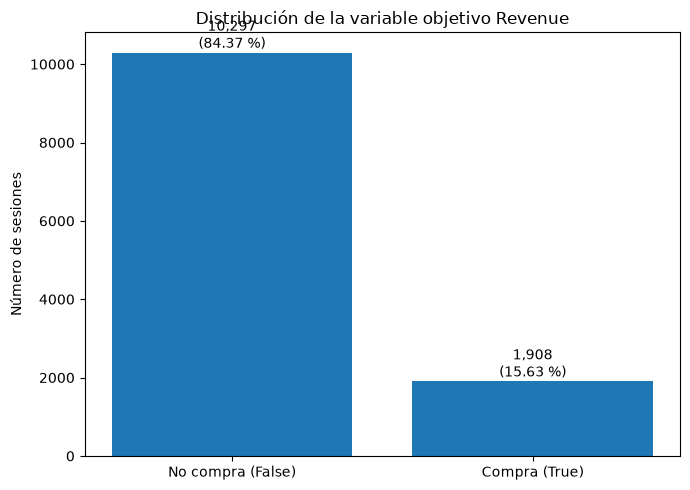

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\revenue_distribution.png


In [17]:
import matplotlib.pyplot as plt


revenue_counts = (
    df_clean["Revenue"]
    .value_counts()
    .sort_index()
)

revenue_percentages = (
    revenue_counts
    / revenue_counts.sum()
    * 100
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No compra (False)", "Compra (True)"],
    revenue_counts.values,
)

ax.set_title("Distribución de la variable objetivo Revenue")
ax.set_ylabel("Número de sesiones")

for bar, count, percentage in zip(
    bars,
    revenue_counts.values,
    revenue_percentages.values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f} %)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

revenue_figure_path = (
    project_root
    / "reports"
    / "revenue_distribution.png"
)

plt.savefig(
    revenue_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada en:")
print(revenue_figure_path)

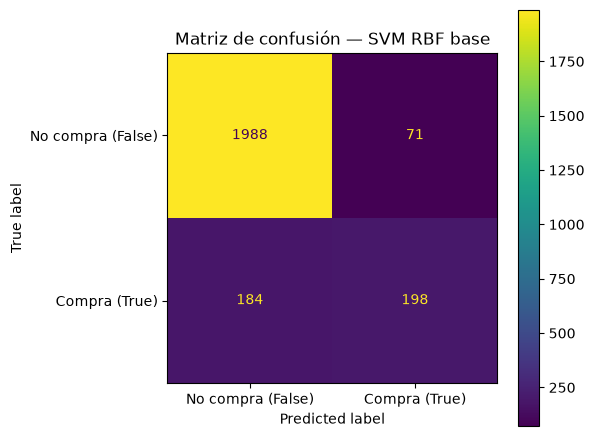

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\svm_confusion_matrix.png


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=[
        "No compra (False)",
        "Compra (True)",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title("Matriz de confusión — SVM RBF base")

plt.tight_layout()

confusion_figure_path = (
    project_root
    / "reports"
    / "svm_confusion_matrix.png"
)

plt.savefig(
    confusion_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada en:")
print(confusion_figure_path)